   recency  frequency   avg_value  engagement true_segment
0       14          2   81.271140    0.688947      passive
1       90          3   30.882894    0.282030       active
2       39          7   24.627765    0.255860      passive
3       27          0   15.685513    0.574739      passive
4        5          0  101.225803    0.202269      passive
true_segment
passive    0.6759
active     0.3241
Name: proportion, dtype: float64


C:\Users\ekadw\AppData\Local\Temp\ipykernel_7204\1723833161.py:157: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  s = torch.tensor([b.s for b in batch], dtype=torch.float32)


Episode 500, eps 0.850, avg_reward(last500) 0.5051
Episode 1000, eps 0.700, avg_reward(last500) 0.5245
Episode 1500, eps 0.550, avg_reward(last500) 0.5464
Episode 2000, eps 0.400, avg_reward(last500) 0.4790
Episode 2500, eps 0.250, avg_reward(last500) 0.5661
Episode 3000, eps 0.100, avg_reward(last500) 0.5683
Episode 3500, eps 0.100, avg_reward(last500) 0.5757
Episode 4000, eps 0.100, avg_reward(last500) 0.5641
Training finished
Average reward: 0.5884333333333335
Purchase rate: 0.6083333333333333
                reward  purchased    action
true_segment                               
active        0.608548   0.628426  0.993909
passive       0.578600   0.598511  0.995533

Action distribution by segment (fraction):
action               0         1
true_segment                    
active        0.006965  0.993035
passive       0.004010  0.995990
Notebook cells finished. Run cells interactively.


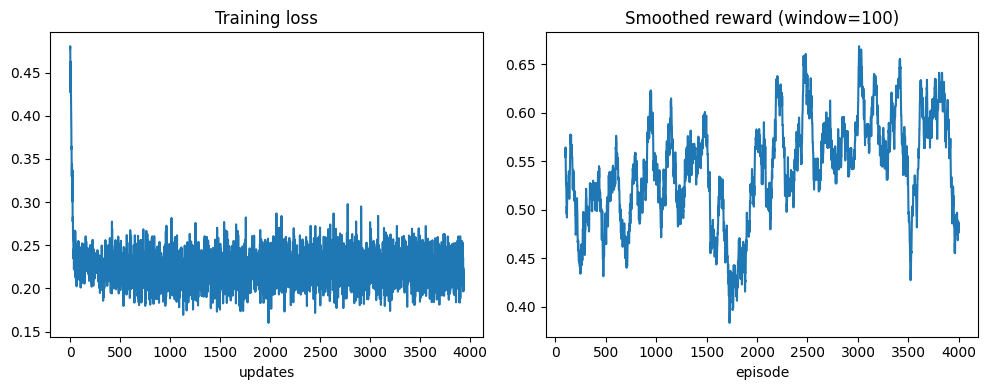

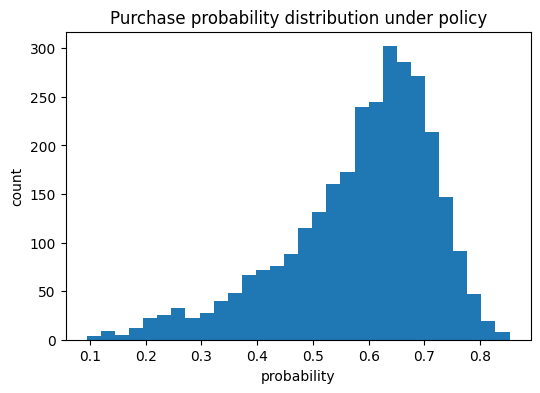

In [1]:
# %%
"""
Jupyter-ready Python script for Reinforcement Learning on Consumer Segmentation
- Synthetic dataset with 10,000 users (active / passive segments)
- A simple Gym-like environment where each episode selects a user and the agent chooses an action:
    0 = no contact
    1 = recommend product (free)
    2 = send discount (costly but higher purchase probability)
- A Deep Q-Network (DQN) implemented in PyTorch trains to maximize expected reward (purchases minus costs)

Run this as a notebook (cells separated by `# %%`) or as a .py script.
"""

# %%
# Imports
import numpy as np
import pandas as pd
import math
import random
from collections import deque, namedtuple
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# For reproducibility
RSEED = 42
random.seed(RSEED)
np.random.seed(RSEED)
torch.manual_seed(RSEED)

# %%
# 1) Synthetic dataset generation (10,000 rows)
N = 10000

# We'll generate features that commonly appear in consumer datasets:
# recency: days since last purchase (0..365)
# frequency: purchases in last 90 days (0..50)
# avg_value: average basket value (10..500)
# engagement_score: 0..1 (derived from site visits / email clicks)
# true_segment: 'active' or 'passive' (target segmentation used for analysis)

recency = np.clip(np.random.exponential(scale=30, size=N).astype(int), 0, 365)
frequency = np.clip(np.random.poisson(lam=2 + (50/(recency+30))), 0, 50)
avg_value = np.random.normal(loc=80 + (15 * (frequency>3)), scale=40, size=N)
avg_value = np.clip(avg_value, 5, 1000)
engagement = np.clip(np.random.beta(2 + (frequency/10), 5 - (frequency/30), size=N), 0, 1)

# True segment: probability of being active increases with frequency & engagement & low recency
active_prob = (0.15 + 0.5 * (frequency / (frequency.max()+1)) + 0.3 * engagement - 0.001 * recency)
active_prob = np.clip(active_prob, 0, 1)
true_segment = np.where(np.random.rand(N) < active_prob, 'active', 'passive')

df = pd.DataFrame({
    'recency': recency,
    'frequency': frequency,
    'avg_value': avg_value,
    'engagement': engagement,
    'true_segment': true_segment
})

# Quick look
print(df.head())
print(df.true_segment.value_counts(normalize=True))

# %%
# 2) Define the environment
# This is a simple episodic environment: each episode samples a user index and returns a state.
# The agent picks an action; environment simulates whether the user purchases based on a logistic
# model that takes the state and action into account. Rewards are: +1 for purchase, minus cost for action.

class ConsumerEnv:
    def __init__(self, dataframe, seed=RSEED, discount_cost=0.2):
        self.df = dataframe.reset_index(drop=True)
        self.n = len(self.df)
        self.rng = np.random.RandomState(seed)
        self.discount_cost = discount_cost  # cost when sending discount (action 2)
        self.action_space = 3  # 0: no-contact, 1: recommend, 2: discount
        self.state_dim = 4  # recency, frequency, avg_value, engagement

    def reset(self, index=None):
        # Sample a random user if index is None
        if index is None:
            self.idx = self.rng.randint(0, self.n)
        else:
            self.idx = index
        row = self.df.loc[self.idx]
        self.state = np.array([row.recency, row.frequency, row.avg_value, row.engagement], dtype=float)
        # Normalize state for agent use
        self.state = self._normalize(self.state)
        return self.state.copy()

    def step(self, action):
        """Perform action and return next_state, reward, done, info"""
        # Use a logistic model for base purchase probability
        row = self.df.loc[self.idx]
        # Base logit uses features with hand-coded weights
        # (in real life this would come from data)
        logit = (
            -0.02 * row.recency +
            0.5 * min(row.frequency, 10) / 10 +
            0.002 * row.avg_value +
            1.4 * row.engagement
        )
        base_prob = 1 / (1 + math.exp(-logit))

        # Action modifiers: no-contact 0, recommend + small bump, discount + bigger bump
        if action == 0:
            prob = base_prob * 0.9  # if you do nothing, slightly lower chance
            cost = 0.0
        elif action == 1:
            prob = base_prob + 0.08 * (1 - base_prob)
            cost = 0.02
        elif action == 2:
            prob = base_prob + 0.22 * (1 - base_prob)
            cost = self.discount_cost
        else:
            raise ValueError('Invalid action')

        prob = np.clip(prob, 0, 1)

        purchased = self.rng.rand() < prob
        reward = (1.0 if purchased else 0.0) - cost

        done = True  # single-step episode per user
        info = {'purchased': purchased, 'purchase_prob': prob, 'base_prob': base_prob, 'cost': cost}

        # No next_state transition — environment ends. Return same normalized state
        return self.state.copy(), reward, done, info

    def _normalize(self, state):
        # Simple normalization with dataset statistics
        s = state.copy().astype(float)
        s[0] = s[0] / 365.0  # recency
        s[1] = s[1] / 50.0   # frequency
        s[2] = s[2] / 1000.0 # avg_value
        s[3] = s[3]          # engagement already 0..1
        return s

# Create env
env = ConsumerEnv(df)

# %%
# 3) Simple DQN implementation (PyTorch)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        self.experience = namedtuple('Experience', ['s', 'a', 'r', 'ns', 'done'])

    def push(self, s, a, r, ns, done):
        self.buffer.append(self.experience(s, a, r, ns, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s = torch.tensor([b.s for b in batch], dtype=torch.float32)
        a = torch.tensor([b.a for b in batch], dtype=torch.long)
        r = torch.tensor([b.r for b in batch], dtype=torch.float32)
        ns = torch.tensor([b.ns for b in batch], dtype=torch.float32)
        done = torch.tensor([b.done for b in batch], dtype=torch.float32)
        return s, a, r, ns, done

    def __len__(self):
        return len(self.buffer)

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# hyperparams
state_dim = env.state_dim
action_dim = env.action_space
buffer_capacity = 20000
batch_size = 64
gamma = 0.99
lr = 1e-3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=lr)
replay = ReplayBuffer(buffer_capacity)

# %%
# 4) Training loop

eps_start = 1.0
eps_end = 0.1
eps_decay = 3000  # number of episodes for decay

num_episodes = 4000
update_target_every = 200

steps_done = 0

def select_action(state, eps_threshold):
    if random.random() < eps_threshold:
        return random.randrange(action_dim)
    else:
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            qvals = policy_net(s)
        return int(qvals.argmax().cpu().numpy())

loss_history = []
reward_history = []

for ep in range(1, num_episodes + 1):
    # linear epsilon decay
    eps = eps_end + (eps_start - eps_end) * max(0, (eps_decay - ep) / eps_decay)

    s = env.reset()
    action = select_action(s, eps)
    ns, r, done, info = env.step(action)

    replay.push(s, action, r, ns, done)
    reward_history.append(r)

    # only learn when buffer large enough
    if len(replay) >= batch_size:
        ss, aa, rr, nss, dd = replay.sample(batch_size)
        ss = ss.to(device); aa = aa.to(device); rr = rr.to(device); nss = nss.to(device); dd = dd.to(device)

        # compute Q(s,a)
        q_values = policy_net(ss).gather(1, aa.unsqueeze(1)).squeeze(1)
        # compute target
        with torch.no_grad():
            next_q = target_net(nss).max(1)[0]
            target = rr + gamma * next_q * (1 - dd)

        loss = nn.functional.mse_loss(q_values, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    # update target network
    if ep % update_target_every == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if ep % 500 == 0:
        avg_r = np.mean(reward_history[-500:])
        print(f'Episode {ep}, eps {eps:.3f}, avg_reward(last500) {avg_r:.4f}')

print('Training finished')

# %%
# 5) Evaluation: run policy on a test subset and compute metrics by true_segment

def run_policy(env, policy_net, df, n_samples=2000):
    policy_net.eval()
    rng = np.random.RandomState(RSEED+1)
    results = []
    for _ in range(n_samples):
        idx = rng.randint(0, len(df))
        s = env.reset(index=idx)
        a = select_action(s, eps_threshold=0.0)  # greedy
        ns, r, done, info = env.step(a)
        rec = df.loc[idx].to_dict()
        rec.update({'action': a, 'reward': r, 'purchased': info['purchased'], 'purchase_prob': info['purchase_prob']})
        results.append(rec)
    return pd.DataFrame(results)

results = run_policy(env, policy_net, df, n_samples=3000)

# Average reward and purchase rate
print('Average reward:', results.reward.mean())
print('Purchase rate:', results.purchased.mean())

# Group by true_segment
print(results.groupby(df['true_segment']).agg({'reward':'mean', 'purchased':'mean', 'action':'mean'}))

# %%
# 6) Quick analyses and plots

# Plot training loss and rewards
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title('Training loss')
plt.xlabel('updates')

plt.subplot(1,2,2)
plt.plot(pd.Series(reward_history).rolling(100).mean())
plt.title('Smoothed reward (window=100)')
plt.xlabel('episode')
plt.tight_layout()

# Show how policy actions differ across segments
action_by_segment = results.groupby('true_segment')['action'].value_counts(normalize=True).unstack().fillna(0)
print('\nAction distribution by segment (fraction):')
print(action_by_segment)

# Plot purchase prob distribution
plt.figure(figsize=(6,4))
plt.hist(results['purchase_prob'], bins=30)
plt.title('Purchase probability distribution under policy')
plt.xlabel('probability')
plt.ylabel('count')

# %%
# 7) Wrap-up suggestions / next steps (as comments)
# - This demo used a synthetic dataset and a simple single-step environment. In production,
#   you'd want to model multi-step interactions, long-term CLV, and richer state transitions.
# - Consider using actor-critic or policy gradient methods if rewards become sparse or
#   the action space grows.
# - Add user-level episode sequences: e.g., simulate sessions over multiple days and let
#   the agent learn long-term effects (retention, lifetime value) rather than immediate purchase.
# - If you have real data, consider training a purchase-propensity model first and using
#   it to construct environment dynamics for offline RL (model-based RL / batch RL).

# %%
# If you want this saved as a notebook file from within the script runtime, you could use nbformat
# to write an .ipynb — but this file is already structured for use in a notebook environment.

print('Notebook cells finished. Run cells interactively.')
